# Road Accident Analysis — 02 Analysis

When crashes happen, how severe they are, and what conditions surround them.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()
sev={1:'Fatal',2:'Serious',3:'Slight'}
df['severity']=df['collision_severity'].map(sev)
print('collisions',len(df))

collisions 101087


## 1. Severity breakdown

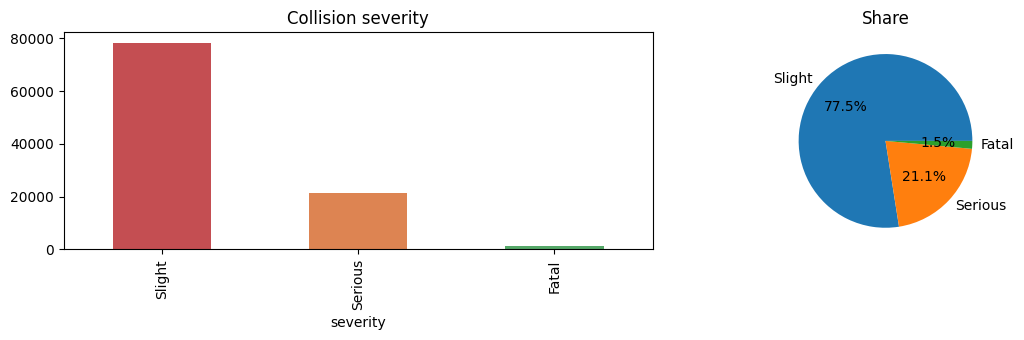

{'Slight': 78329, 'Serious': 21284, 'Fatal': 1474}


In [2]:
sc=df['severity'].value_counts()
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
sc.plot(kind='bar',ax=ax[0],color=['#c44e52','#dd8452','#55a868']); ax[0].set_title('Collision severity')
ax[1].pie(sc,labels=sc.index,autopct='%1.1f%%'); ax[1].set_title('Share')
plt.tight_layout(); plt.show()
print(sc.to_dict())

## 2. When do crashes happen? (day + hour)

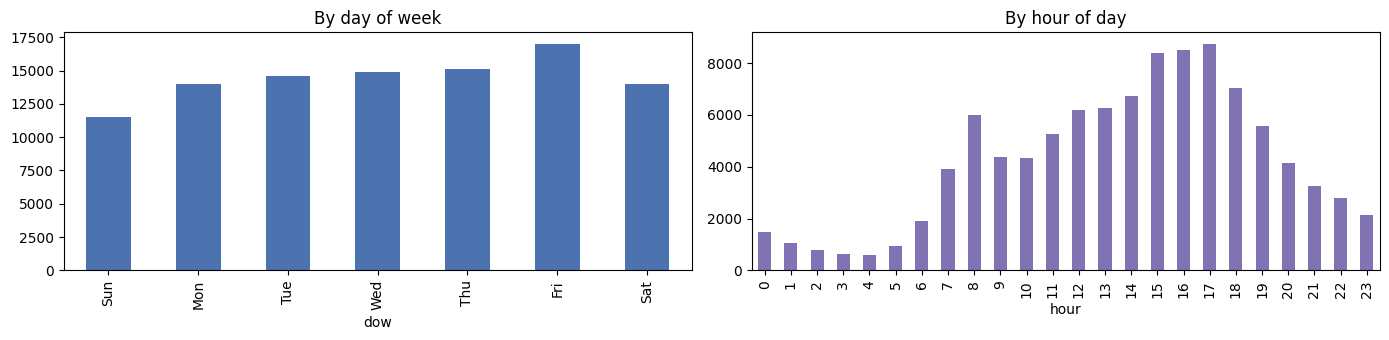

In [3]:
dow={1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'}
df['dow']=df['day_of_week'].map(dow)
df['hour']=pd.to_datetime(df['time'],format='%H:%M',errors='coerce').dt.hour
fig,ax=plt.subplots(1,2,figsize=(14,3.5))
df['dow'].value_counts().reindex(list(dow.values())).plot(kind='bar',ax=ax[0],color='#4c72b0'); ax[0].set_title('By day of week')
df['hour'].value_counts().sort_index().plot(kind='bar',ax=ax[1],color='#8172b3'); ax[1].set_title('By hour of day')
plt.tight_layout(); plt.show()

## 3. Speed limit & conditions

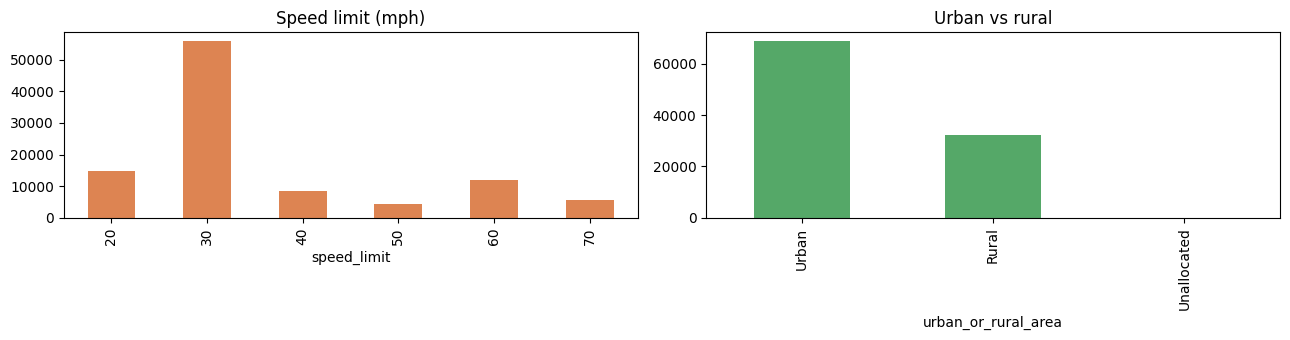

In [4]:
fig,ax=plt.subplots(1,2,figsize=(13,3.5))
df['speed_limit'].value_counts().sort_index().plot(kind='bar',ax=ax[0],color='#dd8452'); ax[0].set_title('Speed limit (mph)')
df['urban_or_rural_area'].map({1:'Urban',2:'Rural',3:'Unallocated'}).value_counts().plot(kind='bar',ax=ax[1],color='#55a868'); ax[1].set_title('Urban vs rural')
plt.tight_layout(); plt.show()

## 4. Severity by speed limit

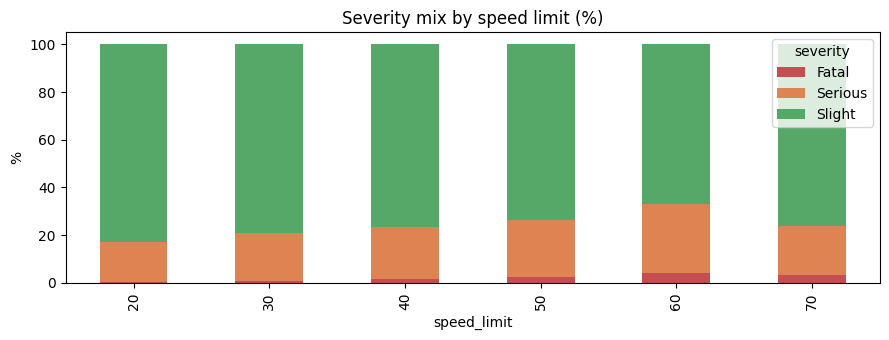

fatal share at 60mph vs 30mph:
speed_limit
30    0.9
60    4.1


In [5]:
ct=pd.crosstab(df['speed_limit'],df['severity'],normalize='index')
fig,ax=plt.subplots(figsize=(9,3.5)); (ct*100).plot(kind='bar',stacked=True,ax=ax,color=['#c44e52','#dd8452','#55a868']); ax.set_title('Severity mix by speed limit (%)'); ax.set_ylabel('%'); plt.tight_layout(); plt.show()
print('fatal share at 60mph vs 30mph:')
print((ct*100)['Fatal'].loc[[30,60]].round(1).to_string() if 30 in ct.index and 60 in ct.index else 'n/a')

## 5. Key findings

- **101,087 collisions in 2021**: **77.5% slight, 21.1% serious, 1.5% fatal** (1,474 fatal crashes).
- **Crashes peak Friday and at the 15:00–18:00 evening rush** (school-run + commute) — timing is dominated by traffic exposure.
- **~68% happen in urban areas** (more vehicles, junctions), but…
- **rural / high-speed roads are deadlier per crash** — the fatal share rises sharply from 30mph to 60mph roads: higher speed → far higher lethality even though urban crashes are more frequent.
- Most collisions involve ~1.8 vehicles and ~1.3 casualties — the typical crash is a low-count urban prang; the fatalities cluster on fast roads.